In [ ]:
import shutil
import os

import kagglehub
from google.colab import drive
drive.mount('/content/drive')

# Download latest version
path = kagglehub.dataset_download("masoudnickparvar/brain-tumor-mri-dataset")

print("Path to dataset files:", path)


# Define your destination on Google Drive
destination = '/content/drive/MyDrive/brain_tumor_dataset'

# Copy the files from the cache to Drive
if not os.path.exists(destination):
    shutil.copytree(path, destination)
    print(f"Dataset moved to: {destination}")
else:
    print("Folder already exists in Drive.")

Mounted at /content/drive
Using Colab cache for faster access to the 'brain-tumor-mri-dataset' dataset.
Path to dataset files: /kaggle/input/brain-tumor-mri-dataset
Dataset moved to: /content/drive/MyDrive/brain_tumor_dataset


In [ ]:
import torch
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import os

# For displaying a grid of images
import torchvision.utils

In [ ]:
!ls /content/drive/MyDrive/brain_tumor_dataset

Testing  Training


In [ ]:
    # Define paths to your data directories
train_dir = '/content/drive/MyDrive/brain_tumor_dataset/Training'
test_dir = '/content/drive/MyDrive/brain_tumor_dataset/Testing'

# Define the transformations for the training and testing sets
# We resize all images to 224x224 as this is a standard input size for many models
# We convert images to tensors and normalize them
data_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])
train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(), # Randomly flip images horizontally
    transforms.RandomRotation(10),     # Randomly rotate images by up to 10 degrees
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# For testing, we only resize, convert to tensor, and normalize
test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])


In [ ]:
import torch
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import os

# For displaying a grid of images
import torchvision.utils

In [ ]:
# Create datasets using ImageFolder
train_dataset = datasets.ImageFolder(train_dir, transform=train_transforms)
test_dataset = datasets.ImageFolder(test_dir, transform=test_transforms)

# Create data loaders to load data in batches
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=32, shuffle=False)

# Get class names
class_names = train_dataset.classes
print(f"Class names: {class_names}")
print(f"Number of training images: {len(train_dataset)}")
print(f"Number of testing images: {len(test_dataset)}")

Class names: ['glioma', 'meningioma', 'notumor', 'pituitary']
Number of training images: 5712
Number of testing images: 1311


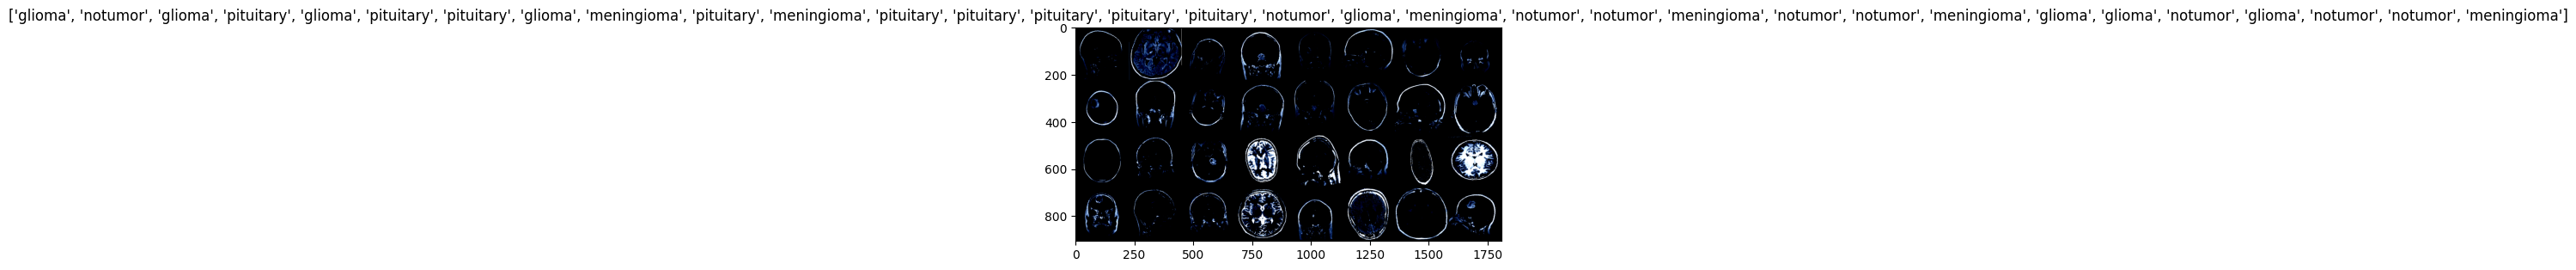

In [ ]:
# Get a batch of training data
images, labels = next(iter(train_loader))

# Make a grid from the batch
grid = torchvision.utils.make_grid(images)

# Plot the images
plt.imshow(grid.numpy().transpose((1, 2, 0)))
plt.title([class_names[x] for x in labels])
plt.show()


In [ ]:
# Check if GPU is available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [ ]:
import timm
import torch.nn as nn

class HybridTumorModel(nn.Module):
    def __init__(self, num_classes=4):
        super(HybridTumorModel, self).__init__()
        # Load ConvNeXt - Good for local textures
        self.convnext = timm.create_model('convnext_tiny', pretrained=True, num_classes=num_classes)
        # Load Vision Transformer (ViT) - Good for global patterns
        self.vit = timm.create_model('vit_tiny_patch16_224', pretrained=True, num_classes=num_classes)

    def forward(self, x):
        out1 = self.convnext(x)
        out2 = self.vit(x)
        # Ensemble Fusion: Average predictions to reduce individual model errors
        return (out1 + out2) / 2

model = HybridTumorModel(num_classes=len(class_names)).to(device)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/22.9M [00:00<?, ?B/s]

In [ ]:
import torch.optim as optim
import torch.nn as nn
from torch.optim.lr_scheduler import StepLR
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import torch

# Get the labels for the entire training dataset
train_labels = train_dataset.targets

# Calculate class weights to handle imbalance
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)

# Convert weights to a PyTorch tensor and move to the selected device
class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

# Define the loss function, now with the calculated weights
criterion = nn.CrossEntropyLoss(weight=class_weights)

# Define the optimizer
optimizer = optim.Adam(model.parameters(), lr=0.0001)

# Define the scheduler to reduce the learning rate every 7 epochs
scheduler = StepLR(optimizer, step_size=7, gamma=0.1)

print(f"Using Calculated Class Weights: {class_weights}")




Using Calculated Class Weights: tensor([1.0810, 1.0665, 0.8953, 0.9801], device='cuda:0')


In [ ]:
# Number of epochs to train for
import copy

num_epochs = 15
patience = 3
patience_counter = 0
best_val_loss = float('inf')
best_model_wts = copy.deepcopy(model.state_dict())
print("Starting Training with ViT + ConvNext..")

for epoch in range(num_epochs):
    model.train()  # Set the model to training mode

    running_loss = 0.0
    for images, labels in train_loader:
        # Move inputs and labels to the device
        images, labels = images.to(device), labels.to(device)

        # Zero the parameter gradients
        optimizer.zero_grad()

        # Forward pass: compute predicted outputs
        outputs = model(images)

        # This line ensures labels are in the correct format [batch_size]
        if labels.ndim > 1:
            labels = torch.argmax(labels, dim=1)

        # Calculate the loss using our weighted criterion
        loss = criterion(outputs, labels)

        # Backward pass: compute gradient of the loss
        loss.backward()

        # Perform a single optimization step (parameter update)
        optimizer.step()

        # Accumulate the loss
        running_loss += loss.item() * images.size(0)

    # Calculate the average loss for the epoch
    epoch_train_loss = running_loss / len(train_dataset)

    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
       for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            val_loss += loss.item() * images.size(0)

            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    epoch_val_loss = val_loss / len(test_dataset)
    val_acc = 100 * correct / total

    print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {epoch_train_loss:.4f} | Val Loss: {epoch_val_loss:.4f} | Val Acc: {val_acc:.2f}%")

    # --- EARLY STOPPING & BEST MODEL SAVING LOGIC ---
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        best_model_wts = copy.deepcopy(model.state_dict())
        torch.save(model.state_dict(), 'best_hybrid_tumor_model.pth')
        patience_counter = 0 # Reset counter
        print(f"--> Best model saved (Val Loss improved to {best_val_loss:.4f})")
    else:
        patience_counter += 1
        print(f"--> No improvement for {patience_counter} epoch(s).")

    if patience_counter >= patience:
        print(f"Early stopping triggered at epoch {epoch+1}. Training Complete.")
        break

# Load the best weights back into the model for final use
model.load_state_dict(best_model_wts)
print("Best weights loaded. Ready for evaluation/deployment.")

Starting Training with ViT + ConvNext..
Epoch 1/15 | Train Loss: 0.0283 | Val Loss: 0.0901 | Val Acc: 97.18%
--> Best model saved (Val Loss improved to 0.0901)
Epoch 2/15 | Train Loss: 0.0245 | Val Loss: 0.0496 | Val Acc: 98.70%
--> Best model saved (Val Loss improved to 0.0496)
Epoch 3/15 | Train Loss: 0.0307 | Val Loss: 0.0367 | Val Acc: 98.86%
--> Best model saved (Val Loss improved to 0.0367)
Epoch 4/15 | Train Loss: 0.0200 | Val Loss: 0.1284 | Val Acc: 96.11%
--> No improvement for 1 epoch(s).
Epoch 5/15 | Train Loss: 0.0351 | Val Loss: 0.0483 | Val Acc: 98.63%
--> No improvement for 2 epoch(s).
Epoch 6/15 | Train Loss: 0.0329 | Val Loss: 0.0678 | Val Acc: 97.48%
--> No improvement for 3 epoch(s).
Early stopping triggered at epoch 6. Training Complete.
Best weights loaded. Ready for evaluation/deployment.


In [ ]:
import torch
import numpy as np

# Lists to store predictions and true labels
all_preds = []
all_labels = []

model.eval()  # Set the model to evaluation mode
with torch.no_grad():  # Disable gradient calculation
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        # Get model outputs
        outputs = model(images)

        # Get the predicted class (the one with the highest score)
        _, predicted = torch.max(outputs.data, 1)

        # Append batch predictions and labels to the lists
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print("Evaluation complete.")

Evaluation complete.


In [ ]:
from sklearn.metrics import classification_report, accuracy_score

# Calculate overall accuracy
accuracy = accuracy_score(all_labels, all_preds)
print(f"Accuracy on the test set: {accuracy * 100:.2f}%\n")

# Generate the detailed classification report
# This shows precision, recall, and F1-score for each class
report = classification_report(all_labels, all_preds, target_names=class_names)
print(report)

Accuracy on the test set: 98.86%

              precision    recall  f1-score   support

      glioma       1.00      0.97      0.99       300
  meningioma       0.97      0.99      0.98       306
     notumor       1.00      1.00      1.00       405
   pituitary       0.99      0.99      0.99       300

    accuracy                           0.99      1311
   macro avg       0.99      0.99      0.99      1311
weighted avg       0.99      0.99      0.99      1311



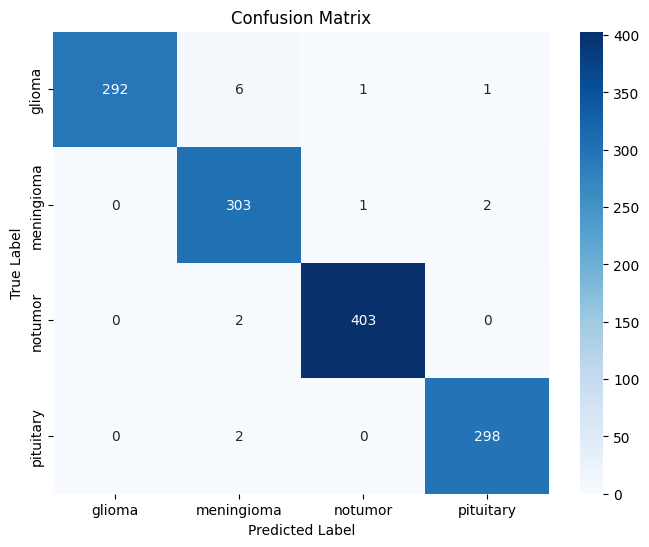

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Generate the confusion matrix
cm = confusion_matrix(all_labels, all_preds)

# Plot the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

In [ ]:

torch.save(model.state_dict(), 'tumor_classifier_model.pth')

In [ ]:
# 1. Identify the correct model object and layer
if hasattr(model, 'convnext'):
    # If 'model' is your HybridTumorModel wrapper
    print("Using Hybrid wrapper...")
    target_layers = [model.convnext.stages[-1].blocks[-1]]
    model_to_use = model
else:
    # If 'model' has become the inner ConvNeXt model directly
    print("Using ConvNeXt model directly...")
    target_layers = [model.stages[-1].blocks[-1]]
    model_to_use = model

# 2. Re-initialize Grad-CAM with the verified model and layer
cam = GradCAM(model=model_to_use, target_layers=target_layers)

def plot_gradcam(image_tensor, label_idx):
    input_tensor = image_tensor.unsqueeze(0).to(device)

    # We use model_to_use here to ensure consistency
    targets = [ClassifierOutputTarget(label_idx)]
    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)
    grayscale_cam = grayscale_cam[0, :]

    img_show = image_tensor.permute(1, 2, 0).cpu().numpy()
    img_show = img_show * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
    img_show = np.clip(img_show, 0, 1)

    visualization = show_cam_on_image(img_show, grayscale_cam, use_rgb=True)
    return img_show, visualization

# Now run your display loop again...

Using ConvNeXt model directly...


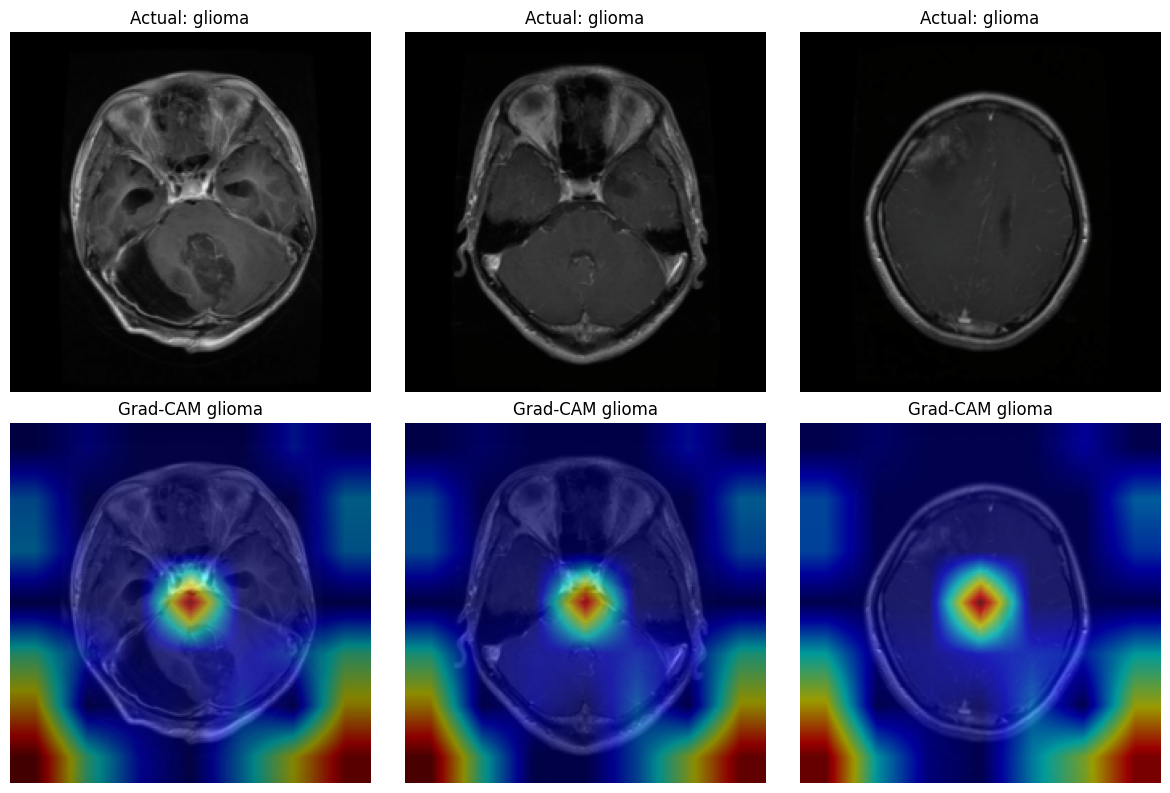

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
import cv2
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

# 1. Setup Target Layer (Targeting the last block of the last stage)
target_layers = [model.stages[-1].blocks[-1]]

# 2. Initialize Grad-CAM
cam = GradCAM(model=model, target_layers=target_layers)

def get_gradcam_result(img_tensor, label_idx):
    # Prepare input
    input_tensor = img_tensor.unsqueeze(0).to(device)

    # Generate Heatmap
    targets = [ClassifierOutputTarget(label_idx)]
    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)
    grayscale_cam = grayscale_cam[0, :]

    # Un-normalize image for display
    img_rgb = img_tensor.permute(1, 2, 0).cpu().numpy()
    img_rgb = img_rgb * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
    img_rgb = np.clip(img_rgb, 0, 1)

    # Blend heatmap with original image
    cam_image = show_cam_on_image(img_rgb, grayscale_cam, use_rgb=True)
    return img_rgb, cam_image

# 3. Run on Test Batch
images, labels = next(iter(test_loader))
model.eval()

plt.figure(figsize=(12, 8))
for i in range(3):
    orig, heat = get_gradcam_result(images[i], labels[i].item())

    # Plot Original
    plt.subplot(2, 3, i+1)
    plt.imshow(orig)
    plt.title(f"Actual: {class_names[labels[i]]}")
    plt.axis('off')

    # Plot Grad-CAM
    plt.subplot(2, 3, i+4)
    plt.imshow(heat)
    plt.title(f"Grad-CAM {class_names[labels[i]]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

Mismatch Found!
True Label: meningioma | Predicted: glioma


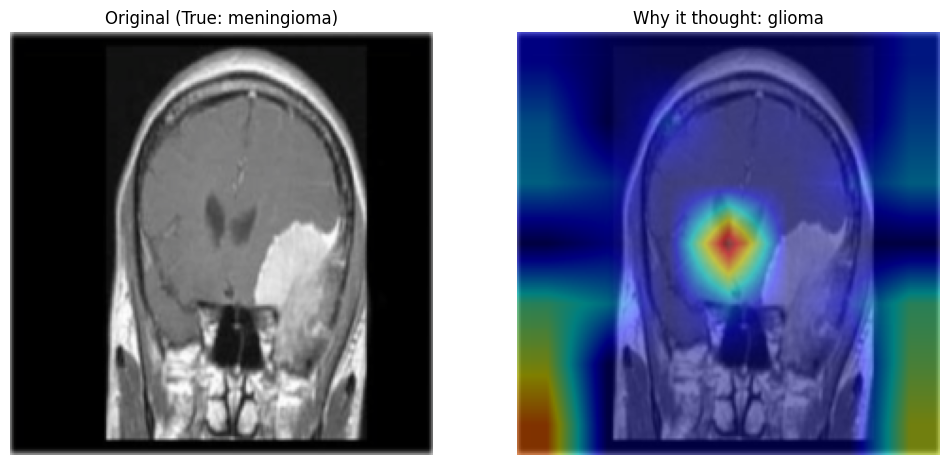

In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
from pytorch_grad_cam.utils.image import show_cam_on_image

# --- STEP 1: Ensure Model is on GPU ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)
model.eval()

# --- STEP 2: Setup Grad-CAM ---
# Targeting the last block of the ConvNeXt model
target_layers = [model.stages[-1].blocks[-1]]
cam = GradCAM(model=model, target_layers=target_layers)

def run_grad_cam_on_image(image_tensor, label_idx):
    # Ensure tensor is on the correct device
    input_tensor = image_tensor.unsqueeze(0).to(device)

    # Generate CAM
    targets = [ClassifierOutputTarget(label_idx)]
    grayscale_cam = cam(input_tensor=input_tensor, targets=targets)
    grayscale_cam = grayscale_cam[0, :]

    # Convert tensor to displayable image
    img_rgb = image_tensor.permute(1, 2, 0).cpu().numpy()
    img_rgb = img_rgb * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
    img_rgb = np.clip(img_rgb, 0, 1)

    # Blend
    visualization = show_cam_on_image(img_rgb, grayscale_cam, use_rgb=True)
    return img_rgb, visualization

# --- STEP 3: Find an Error and Visualize ---
# --- Updated Loop with Grad-CAM Fix ---
found_error = False

# We still use no_grad for the general search to save memory
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        for i in range(len(preds)):
            if preds[i] != labels[i]:
                print(f"Mismatch Found!")
                print(f"True Label: {class_names[labels[i]]} | Predicted: {class_names[preds[i]]}")

                # --- FIX STARTS HERE ---
                # Re-enable gradients locally just for the Grad-CAM calculation
                with torch.set_grad_enabled(True):
                    orig, heat = run_grad_cam_on_image(images[i].cpu(), preds[i].item())
                # --- FIX ENDS HERE ---

                plt.figure(figsize=(12, 6))
                plt.subplot(1, 2, 1)
                plt.imshow(orig)
                plt.title(f"Original (True: {class_names[labels[i]]})")
                plt.axis('off')

                plt.subplot(1, 2, 2)
                plt.imshow(heat)
                plt.title(f"Why it thought: {class_names[preds[i]]}")
                plt.axis('off')
                plt.show()

                found_error = True
                break
        if found_error: break